In [1]:
import pandas as pd

try:
    df = pd.read_excel("GovEnergy.xlsx", sheet_name="Month")
    print(df)

except FileNotFoundError:
    print("Error: The file 'data.xlsx' was not found.")
except ValueError as e:
    print(f"ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

    Table 1.1 Indigenous production of primary fuels, monthly data (million tonnes of oil equivalent)  \
0                    This worksheet contains one table                                                  
1    Some cells refer to notes which can be found o...                                                  
2    Freeze panes are active on this sheet, to turn...                                                  
3           [x] is used to indicate data not available                                                  
4                                                Month                                                  
..                                                 ...                                                  
377                                       January 2026                                                  
378                                      February 2026                                                  
379                                         March 2026 

In [2]:
df = df.dropna()
df


,"Table 1.1 Indigenous production of primary fuels, monthly data (million tonnes of oil equivalent)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
4,Month,Total,Coal [note 1],Petroleum [note 2],Natural gas [note 3],Bioenergy & waste [note 4] [note 5] [note 6],Primary electricity - nuclear [note 7],"Primary electricity - wind, solar and hydro [n..."
5,January 1995,24.5,1.72,12.44,8.69,0.14,1.51,[x]
6,February 1995,23.17,2.67,11.59,7.18,0.14,1.59,[x]
7,March 1995,25.97,3.45,12.73,7.74,0.14,1.91,[x]
8,April 1995,22.38,2.38,12.3,5.78,0.14,1.78,[x]
...,...,...,...,...,...,...,...,...
377,January 2026,8.068,0.008,2.69,2.33,1.34,0.66,1.04
378,February 2026,7.91,0.01,2.78,2.24,1.34,0.62,0.92
379,March 2026,8.329,0.009,2.9,2.5,1.34,0.65,0.93
380,April 2026,7.948,0.008,2.82,2.28,1.14,0.86,0.84


In [3]:
df.index=df["Table 1.1 Indigenous production of primary fuels, monthly data (million tonnes of oil equivalent)"]
df_sorted = df.index[1:]
df_sorted


Index(['January 1995', 'February 1995', 'March 1995', 'April 1995', 'May 1995',
       'June 1995', 'July 1995', 'August 1995', 'September 1995',
       'October 1995',
       ...
       'August 2025', 'September 2025', 'October 2025', 'November 2025',
       'December 2025', 'January 2026', 'February 2026', 'March 2026',
       'April 2026', 'May 2026 [provisional]'],
      dtype='object', name='Table 1.1 Indigenous production of primary fuels, monthly data (million tonnes of oil equivalent)', length=377)

In [4]:
df_sorted = pd.to_datetime(
    df_sorted.str.replace(" [provisional]", "", regex=False),
    format="%B %Y"
)

In [5]:
df_sorted

DatetimeIndex(['1995-01-01', '1995-02-01', '1995-03-01', '1995-04-01',
               '1995-05-01', '1995-06-01', '1995-07-01', '1995-08-01',
               '1995-09-01', '1995-10-01',
               ...
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01',
               '2026-04-01', '2026-05-01'],
              dtype='datetime64[ns]', name='Table 1.1 Indigenous production of primary fuels, monthly data (million tonnes of oil equivalent)', length=377, freq=None)

In [6]:
ngas = df["Unnamed: 4"].rename("N-Gas")
ngas = ngas[1:]
ngas.index = df_sorted
ngas

Table 1.1 Indigenous production of primary fuels, monthly data (million tonnes of oil equivalent)
1995-01-01    8.69
1995-02-01    7.18
1995-03-01    7.74
1995-04-01    5.78
1995-05-01    4.86
              ... 
2026-01-01    2.33
2026-02-01    2.24
2026-03-01     2.5
2026-04-01    2.28
2026-05-01    2.18
Name: N-Gas, Length: 377, dtype: object

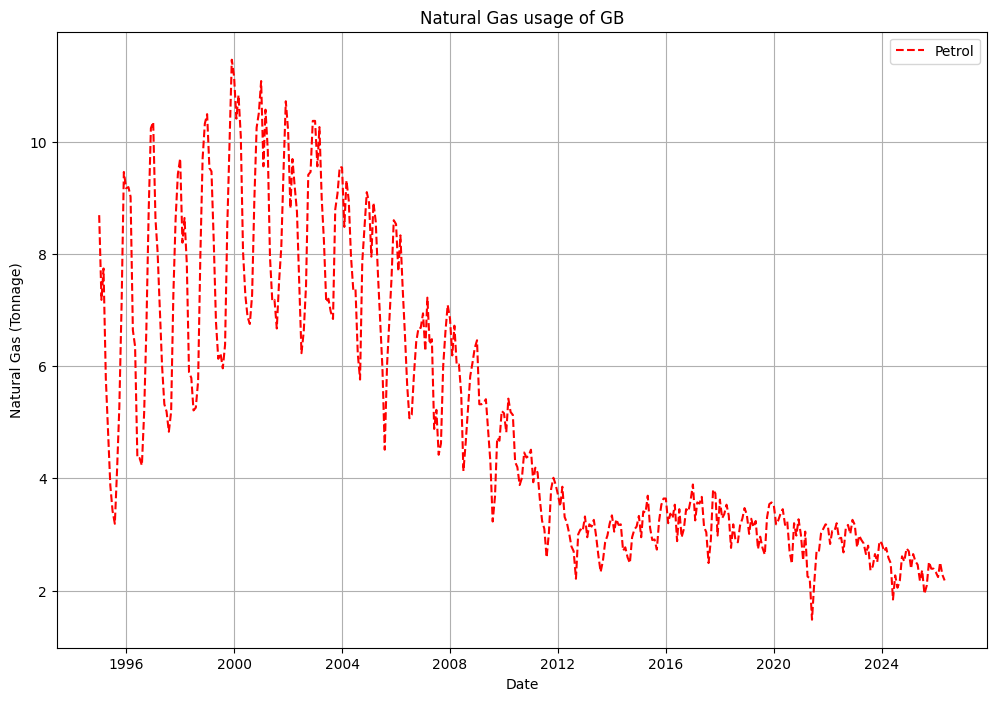

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(ngas, color="red", linestyle="dashed", label="Petrol")
plt.title("Natural Gas usage of GB")
plt.xlabel("Date")
plt.ylabel("Natural Gas (Tonnage)")
plt.legend()
plt.grid(True)
plt.show()






In [9]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: {}'.format(result[0]))
    print('p-value: {}'.format(result[1]))
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))

adf_test(ngas)

ADF Statistic: -0.5227854473482271
p-value: 0.8874928507753319
Critical Values:
	1%: -3.448645946352023
	5%: -2.869602139060357
	10%: -2.5710650077160495


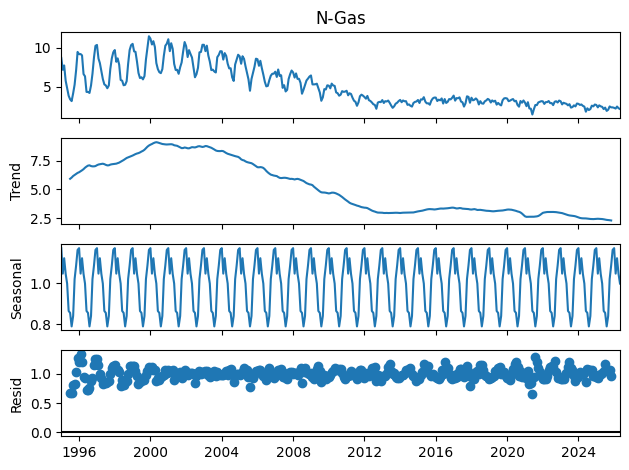

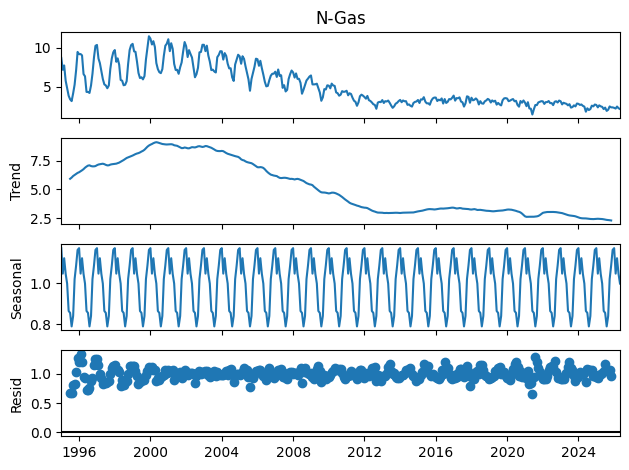

In [10]:
import statsmodels.api as sm
result = sm.tsa.seasonal_decompose(ngas, model='multiplicative', period=12)
trend = result.trend
seasonal = result.seasonal
residual = result.resid

result.plot()


In [11]:
ngas_diff = ngas.diff().dropna()
ngas_seasonal_diff = ngas_diff.diff(12).dropna()


def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: {}'.format(result[0]))
    print('p-value: {}'.format(result[1]))
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))

adf_test(ngas_seasonal_diff)


ADF Statistic: -7.857380059630709
p-value: 5.3973066576318444e-12
Critical Values:
	1%: -3.4491725955218655
	5%: -2.8698334971428574
	10%: -2.5711883591836733


<Figure size 1200x600 with 0 Axes>

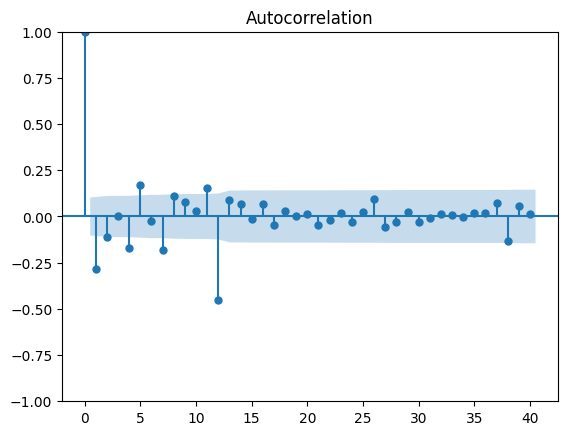

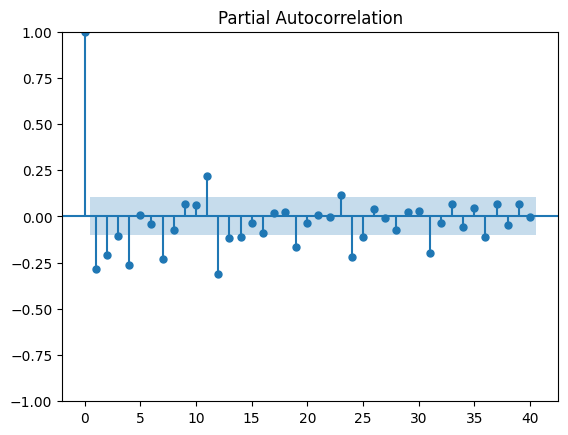

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_acf(ngas_seasonal_diff.dropna(), lags=40)
plot_pacf(ngas_seasonal_diff.dropna(), lags=40)
plt.show()


In [ ]:
ngas = pd.to_numeric(ngas, errors='coerce')
ngas.dtype

dtype('float64')

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(ngas, order=(1,1,1), seasonal_order=(1,1,1,12))     #first middle 1 = differenced which we did and the second middle 1 = seasonal difference
results = model.fit()
print(results.summary())


c:\Users\Invate\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Invate\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              N-Gas   No. Observations:                  377
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -175.851
Date:                            Wed, 19 Aug 2026   AIC                            361.703
Time:                                    18:11:10   BIC                            381.189
Sample:                                01-01-1995   HQIC                           369.448
                                     - 05-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4867      0.058      8.376      0.000       0.373       0.601
ma.L1         -0.8538      0.038   

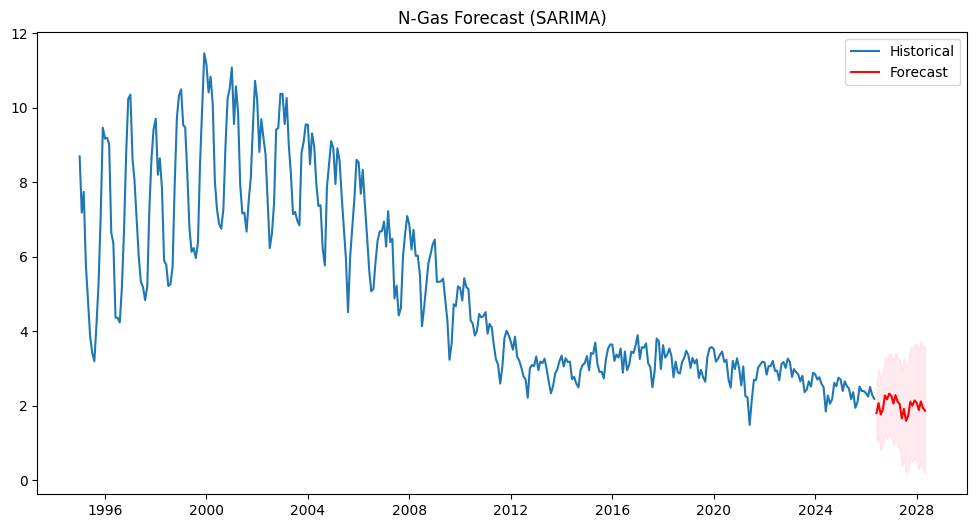

In [15]:
forecast_steps = 24
forecast = results.get_forecast(steps=forecast_steps)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()
future_index = pd.date_range(
    start=ngas.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)
mean_forecast.index = future_index
conf_int.index = future_index


plt.figure(figsize=(12,6))

# Historical
plt.plot(ngas.index, ngas, label='Historical')

# Forecast
plt.plot(mean_forecast.index, mean_forecast, label='Forecast', color='red')

# Confidence intervals
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color='pink',
    alpha=0.3
)

plt.title('N-Gas Forecast (SARIMA)')
plt.legend()
plt.show()


In [16]:
mean_forecast

2026-06-01    1.797276
2026-07-01    2.066722
2026-08-01    1.760730
2026-09-01    1.896770
2026-10-01    2.271403
2026-11-01    2.166234
2026-12-01    2.320760
2027-01-01    2.264288
2027-02-01    2.053912
2027-03-01    2.280983
2027-04-01    2.107536
2027-05-01    2.038337
2027-06-01    1.654539
2027-07-01    1.910119
2027-08-01    1.589307
2027-09-01    1.725573
2027-10-01    2.104449
2027-11-01    1.997390
2027-12-01    2.135217
2028-01-01    2.078297
2028-02-01    1.880781
2028-03-01    2.111361
2028-04-01    1.932920
2028-05-01    1.860418
Freq: MS, Name: predicted_mean, dtype: float64